In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [ ]:
# read in all the words
words = open('/content/sample_data/names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [ ]:
len(words)

32033

In [ ]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:

  # print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    # print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [ ]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [ ]:
C = torch.randn((27,2))
C[5]

tensor([-0.8605,  0.1139])

In [ ]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([-0.8605,  0.1139])

In [ ]:
C[X]

tensor([[[ 0.4664,  2.3484],
         [ 0.4664,  2.3484],
         [ 0.4664,  2.3484]],

        [[ 0.4664,  2.3484],
         [ 0.4664,  2.3484],
         [-0.8605,  0.1139]],

        [[ 0.4664,  2.3484],
         [-0.8605,  0.1139],
         [ 0.9723, -0.3688]],

        [[-0.8605,  0.1139],
         [ 0.9723, -0.3688],
         [ 0.9723, -0.3688]],

        [[ 0.9723, -0.3688],
         [ 0.9723, -0.3688],
         [-2.1247, -0.4530]],

        [[ 0.4664,  2.3484],
         [ 0.4664,  2.3484],
         [ 0.4664,  2.3484]],

        [[ 0.4664,  2.3484],
         [ 0.4664,  2.3484],
         [-2.5281, -0.4522]],

        [[ 0.4664,  2.3484],
         [-2.5281, -0.4522],
         [ 1.4623, -0.8397]],

        [[-2.5281, -0.4522],
         [ 1.4623, -0.8397],
         [ 0.2729,  1.0966]],

        [[ 1.4623, -0.8397],
         [ 0.2729,  1.0966],
         [ 0.8046, -0.3570]],

        [[ 0.2729,  1.0966],
         [ 0.8046, -0.3570],
         [ 0.2729,  1.0966]],

        [[ 0.8046, -0

In [ ]:
X[13,2]

tensor(1)

In [ ]:
C[X][13,2]

tensor([-2.1247, -0.4530])

In [ ]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [ ]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [ ]:
h = torch.tanh(emb.view(-1,6) @ W1 + b1)

In [ ]:
h.shape

torch.Size([32, 100])

In [ ]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [ ]:
logits = h @ W2 + b2

In [ ]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
# probs[0].sum()

In [ ]:
loss = -prob[torch.arange(32), Y].log().mean()

In [ ]:
# ------ now made repectable ------

In [ ]:
embedding_size = 10
block_size = 5 # context length: how many characters do we take to predict the next one?


In [ ]:
# build the dataset
def build_dataset(words):
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182437, 5]) torch.Size([182437])
torch.Size([22781, 5]) torch.Size([22781])
torch.Size([22928, 5]) torch.Size([22928])


In [ ]:
Xtr.shape, Ytr.shape

(torch.Size([182437, 5]), torch.Size([182437]))

In [ ]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, embedding_size), generator=g)
W1 = torch.randn((embedding_size * block_size, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [ ]:
for p in parameters:
  p.requires_grad = True

In [ ]:
lri = []
lossi = []
stepi = []

In [ ]:
for i in range(200000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (64,))

  # forward pass
  emb = C[Xtr[ix]] # (32, block_size, embedding_size)
  h = torch.tanh(emb.view(-1, block_size * embedding_size) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

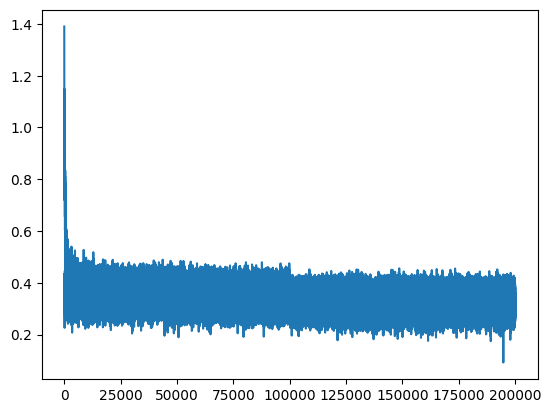

In [ ]:
plt.plot(stepi, lossi)

In [ ]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, block_size * embedding_size) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1098, grad_fn=<NllLossBackward0>)

In [ ]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, block_size * embedding_size) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1537, grad_fn=<NllLossBackward0>)